In [1]:
##################
# Library imports #
###################

import sys
import os
from pathlib import Path

from scipy.integrate import quad

import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

from joblib import Parallel, delayed, dump

from tenpy.networks.mps import MPS
from tenpy.models.model import CouplingMPOModel
from tenpy.networks import site
from tenpy.algorithms.dmrg import TwoSiteDMRGEngine
from tenpy.algorithms import tdvp

In [2]:
################################################################
# Define the time-dependent spinless interacting fermion model #
################################################################

class time_dependent_Hubbard(CouplingMPOModel):

    default_lattice = 'Ladder' # Using ladder to represent sample + probe
    force_default_lattice = True # Ensure we always use the ladder lattice

    def init_sites(self, model_params): 
        fermion_sample = site.SpinHalfFermionSite(cons_N='N', cons_Sz='Sz') # Sample site
        fermion_probe = site.SpinHalfFermionSite(cons_N='N', cons_Sz='Sz') # Probe site
        site.set_common_charges([fermion_sample, fermion_probe], new_charges='same') # Independent charges
        return [fermion_sample, fermion_probe] # Return list of site objects

    def init_terms(self, model_params):

        # Extract parameters
        J = model_params.get('J', 1.0)
        U = model_params.get('U', 10.0)
        #V = model_params.get('V', 5.0)

        g = model_params.get('g', 0.2)
        omega = model_params.get('omega', 1.0)

        mu = model_params.get('mu', 0.0)
 
        # Hopping within the sample
        self.add_coupling(-J, 0, 'Cdu', 0, 'Cu', [1], plus_hc=True)
        self.add_coupling(-J, 0, 'Cdd', 0, 'Cd', [1], plus_hc=True)

        # Onsite interaction in the sample
        self.add_onsite(U, 0, 'NuNd')

        # Neighbor interaction within the sample
        # self.add_coupling(V, 0, 'Ntot', 0, 'Ntot', [1], plus_hc=False)

        # Chemical potential on the sample
        self.add_onsite(mu, 0, 'Ntot')

        # Probe energy term
        self.add_onsite(omega, 1, 'Nu')

        # Interaction between sample and probe
        self.add_coupling(g, 0, 'Cdu', 1, 'Cu', [0], plus_hc=True)
        self.add_coupling(g, 0, 'Cdd', 1, 'Cd', [0], plus_hc=True)

#############
# Functions #
#############

def E_pulse(t, E0, Omega, sigma, t0):
    # Electric field of the pulse
    return E0 * np.exp(-((t - t0)**2) / (2 * sigma**2)) * np.sin(Omega * t)

def A_pulse(E0, Omega, sigma, t0, t):
    # Vector potential from the electric field pulse
    A = np.zeros_like(t)
    for i, ti in enumerate(t):
        A[i], A_error = quad(E_pulse, -np.inf, ti, args=(E0, Omega, sigma, t0))
    return -A, A_error

def correlation_up(psi, model):

    probe_sites = model.lat.mps_idx_fix_u(1) # Probe sites
    C_p = psi.correlation_function('Cdu', 'Cu', sites1=probe_sites, sites2=probe_sites) # Compute correlation function on probe
    
    return C_p

def correlation_down(psi, model):

    probe_sites = model.lat.mps_idx_fix_u(1) # Probe sites
    C_p = psi.correlation_function('Cdd', 'Cd', sites1=probe_sites, sites2=probe_sites) # Compute correlation function on probe
    
    return C_p

def dmrg_ground_state(psi_init, model, dmrg_params):

    dmrg_engine = TwoSiteDMRGEngine(psi_init, model, dmrg_params) # Initialize DMRG engine
    E0, psi_gs = dmrg_engine.run() # Run DMRG to find ground state

    return E0, psi_gs

##################################################################################################
# Main function that runs TDVP for a given omega and returns the correlation functions over time #
##################################################################################################

def simulation(times, omega_val, A, Probe, psi_init, model_parameter, tdvp_params):

    model_params_copy = model_parameter.copy()  # Create a copy to avoid modifying the original

    J0 = model_params_copy.get('J', 1.0)    
    L = model_params_copy['L']
    N_t = len(times)

    C_up = np.zeros((N_t, L, L), dtype=complex)
    C_down = np.zeros((N_t, L, L), dtype=complex)

    psi = psi_init.copy()

    for ti, _ in enumerate(times):

        model_params_copy['J'] = J0 * np.exp(1j * A[ti])
    
        model_params_copy['omega'] = omega_val
    
        model_params_copy['g'] = Probe[ti]
    
        model = time_dependent_Hubbard(model_params_copy)
    
        eng_tdvp = tdvp.TwoSiteTDVPEngine(psi, model, tdvp_params)
    
        eng_tdvp.run()

        psi = eng_tdvp.psi

        C_up[ti, :, :] = correlation_up(psi, model)
        C_down[ti, :, :] = correlation_down(psi, model) 
    
    return C_up, C_down

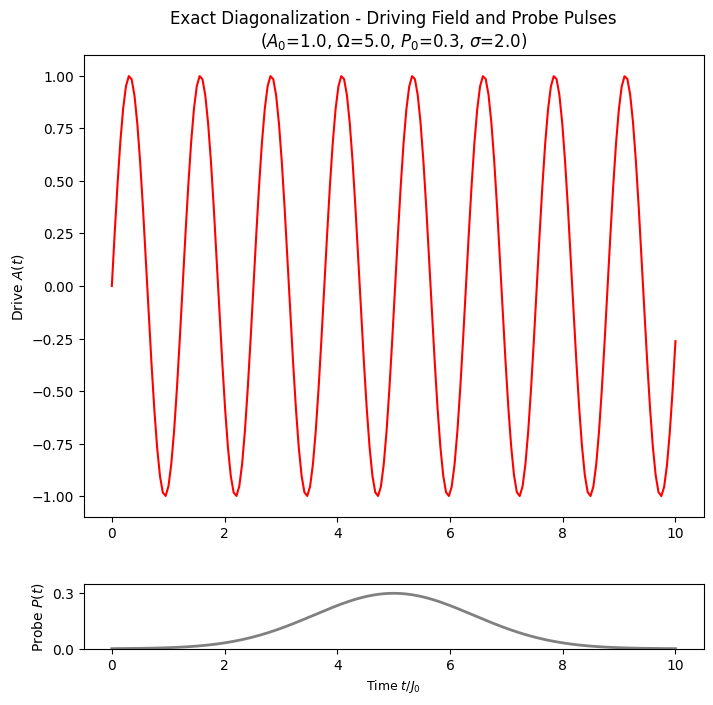

In [5]:
# Comment :
# With the current parameter and 30 cores 
# this code should take around 1 hour to 
# run a mid resolution image !

########
# Time #
########

N_t = 200
times = np.linspace(0.0, 10.0, N_t)
dt = times[1]-times[0]

#########################################################################
# Processing Energy scan array to submit different simultaneously tasks #
#########################################################################

N_omega = 30

omega_scan = np.linspace(-10.0, 10.0, N_omega) 

###################
# Model Paramaters#
###################

L = 32

J0 = 1.0
U0 = 5.0
mu = - U0 

########################
# init Drive and Pulse #
########################

A0 = 1.0
omega_drive = 5.0

A = A0 * np.sin(omega_drive * times)


P0 = 0.3
t_probe = 5.0
sigma = 2.0

Probe = P0 * np.exp(-(times - t_probe)**2 / (sigma**2))

#######################################
# DMRG, TDVP and model parameter dict #
#######################################

dmrg_params = {
    'mixer': True,
    'max_E_err': 1.e-6,
    'trunc_params': {
        'chi_max': 100,
        'svd_min': 1.e-6,
    },
}

tdvp_params = {
    'N_steps': 1,
    'dt': dt,
    'trunc_params': {
        'chi_max': 100, 
        'svd_min': 1.e-6,
    },
}


plt.figure(figsize=(8, 6))
ax_main = plt.gca()

plt.plot(times, A, color='red', label=r'$A(t)$')
 
plt.ylabel(r'Drive $A(t)$')
plt.title(r'Exact Diagonalization - Driving Field and Probe Pulses' + '\n' + r'($A_0$={:.5}, $\Omega$={:.1f}, $P_0$={:.1f}, $\sigma$={:.3})'.format(A0, omega_drive, P0, sigma))

# Add inset axes at the bottom showing only the probe pulse
ax_inset = inset_axes(ax_main, width="100%", height="40%", loc='lower center',
                       bbox_to_anchor=(0.0, -0.3, 1.0, 0.35), 
                       bbox_transform=ax_main.transAxes)

ax_inset.plot(times, Probe, color='gray', linewidth=2)
ax_inset.set_xlabel(r'Time $t/J_0$', fontsize=9)
ax_inset.set_ylabel(r'Probe $P(t)$')
ax_inset.set_ylim(0.0, 0.35)
ax_inset.set_yticks([0.0, 0.3])
plt.show()



In [9]:
print("Model parameters: J0={}, U0={}".format(J0, U0))
print()
print("Drive and Probe: A0={}, omega={}, P0={}, sigma={}".format(A0, omega_drive, P0, sigma))
print()
print("Resolution parameters: N_t={}, N_k={}, N_omega={}".format(N_t, L+1, N_omega))
print()
print("===================================================================================")
print()
print("-> Scanning lower band...")
print()

mu_probe = 10.0**4

s_filling = 1.0 
p_filling = 0.0

Ns = int(s_filling * L / 2)
Np = int(p_filling * L / 2)

model_parameter = {
    'L': L,
    'J': J0,
    'g': 0.0,
    #'V': V0,
    'omega': mu_probe,
    'mu':mu,
    'bc_MPS': 'finite',
    }

model_init = time_dependent_Hubbard(model_parameter)

lattice = model_init.lat

product_state = [
    (f_s, f_p) for f_s, f_p in zip(['up', 'down'] * Ns + ['empty'] * (L - Ns), ['full'] * Np + ['empty'] * (L - 2 * Np))
    ]

psi_init = MPS.from_lat_product_state(lattice, product_state)

E0, psi_gs = dmrg_ground_state(psi_init, model_init, dmrg_params)

sample_occupation = psi_gs.expectation_value('Ntot', sites=lattice.mps_idx_fix_u(0)) 
probe_occupation = psi_gs.expectation_value('Ntot', sites=lattice.mps_idx_fix_u(1))

print(r'Sample occupation before time-evolution: {:.5}'.format(np.mean(sample_occupation)))
print(r'Probe occupation before time-evolution: {:.5}'.format(np.mean(probe_occupation)))
print()

results_bottom = Parallel(n_jobs=-1, verbose=10)(delayed(simulation)(times, w_val, A, Probe, psi_gs, model_parameter, tdvp_params) for w_val in omega_scan)

print()
print("===================================================================================")
print()
print("-> Scanning upper band...")
print()

mu_probe = -10.0**4

s_filling = 1.0 
p_filling = 1.0

Ns = int(s_filling * L / 2)
Np = int(p_filling * L / 2)

model_parameter = {
    'L': L,
    'J': J0,
    'g': 0.0,
#    'V': V0,
    'omega': mu_probe,
    'mu':mu,
    'bc_MPS': 'finite',
    }

model_init = time_dependent_Hubbard(model_parameter)

lattice = model_init.lat

product_state = [
    (f_s, f_p) for f_s, f_p in zip(['up', 'down'] * Ns + ['empty'] * (L - Ns), ['full'] * Np + ['empty'] * (L - 2 * Np))
    ]

psi_init = MPS.from_lat_product_state(lattice, product_state)

E0, psi_gs = dmrg_ground_state(psi_init, model_init, dmrg_params)

sample_occupation = psi_gs.expectation_value('Ntot', sites=lattice.mps_idx_fix_u(0)) 
probe_occupation = psi_gs.expectation_value('Ntot', sites=lattice.mps_idx_fix_u(1))

print(r'Sample occupation before time-evolution: {:.5}'.format(np.mean(sample_occupation)))
print(r'Probe occupation before time-evolution: {:.5}'.format(np.mean(probe_occupation)))
print()

results_top = Parallel(n_jobs=-1, verbose=10)(delayed(simulation)(times, w_val, A, Probe, psi_gs, model_parameter, tdvp_params) for w_val in omega_scan)

print()
print("Simulation completed!")


Model parameters: J0=1.0, U0=5.0

Drive and Probe: A0=0.0, omega=5.0, P0=0.3, sigma=2.0

Resolution parameters: N_t=100, N_k=33, N_omega=30


-> Scanning lower band...

Sample occupation before time-evolution: 1.0
Probe occupation before time-evolution: 1.8218e-18



[Parallel(n_jobs=-1)]: Using backend LokyBackend with 30 concurrent workers.
[Parallel(n_jobs=-1)]: Done   3 out of  30 | elapsed: 30.7min remaining: 275.9min
[Parallel(n_jobs=-1)]: Done   7 out of  30 | elapsed: 31.8min remaining: 104.4min
[Parallel(n_jobs=-1)]: Done  11 out of  30 | elapsed: 32.3min remaining: 55.7min
[Parallel(n_jobs=-1)]: Done  15 out of  30 | elapsed: 32.4min remaining: 32.4min
[Parallel(n_jobs=-1)]: Done  19 out of  30 | elapsed: 33.0min remaining: 19.1min
[Parallel(n_jobs=-1)]: Done  23 out of  30 | elapsed: 34.0min remaining: 10.3min
[Parallel(n_jobs=-1)]: Done  27 out of  30 | elapsed: 34.6min remaining:  3.8min
[Parallel(n_jobs=-1)]: Done  30 out of  30 | elapsed: 35.1min finished




-> Scanning upper band...

Sample occupation before time-evolution: 1.0
Probe occupation before time-evolution: 2.0



[Parallel(n_jobs=-1)]: Using backend LokyBackend with 30 concurrent workers.
[Parallel(n_jobs=-1)]: Done   3 out of  30 | elapsed: 29.9min remaining: 269.0min
[Parallel(n_jobs=-1)]: Done   7 out of  30 | elapsed: 31.5min remaining: 103.6min
[Parallel(n_jobs=-1)]: Done  11 out of  30 | elapsed: 32.1min remaining: 55.4min
[Parallel(n_jobs=-1)]: Done  15 out of  30 | elapsed: 32.3min remaining: 32.3min
[Parallel(n_jobs=-1)]: Done  19 out of  30 | elapsed: 32.6min remaining: 18.9min
[Parallel(n_jobs=-1)]: Done  23 out of  30 | elapsed: 34.4min remaining: 10.5min
[Parallel(n_jobs=-1)]: Done  27 out of  30 | elapsed: 35.3min remaining:  3.9min



Simulation completed!


[Parallel(n_jobs=-1)]: Done  30 out of  30 | elapsed: 35.7min finished


Lower band: C_up shape, C_down shape=((30, 100, 32, 32),(30, 100, 32, 32))
Upper band: C_up shape, C_down shape=((30, 100, 32, 32),(30, 100, 32, 32))


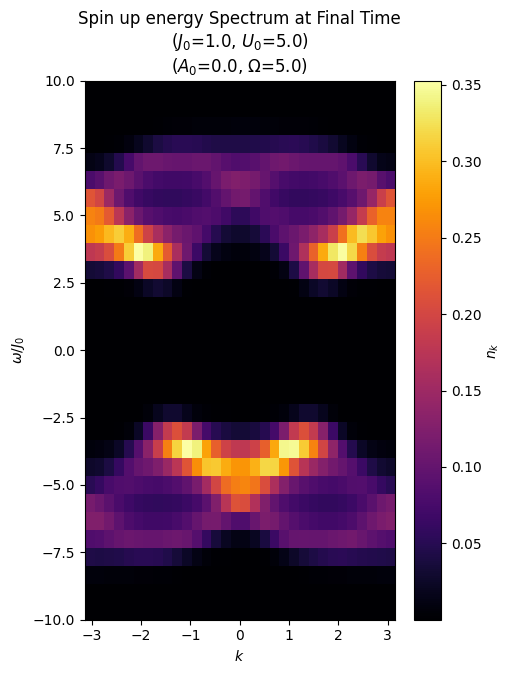

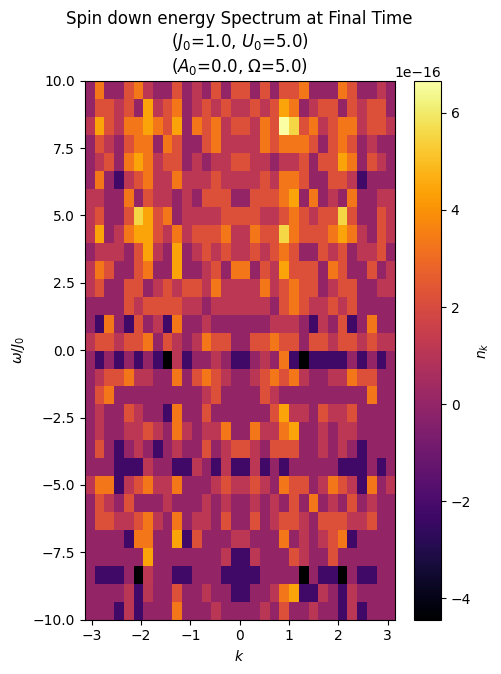

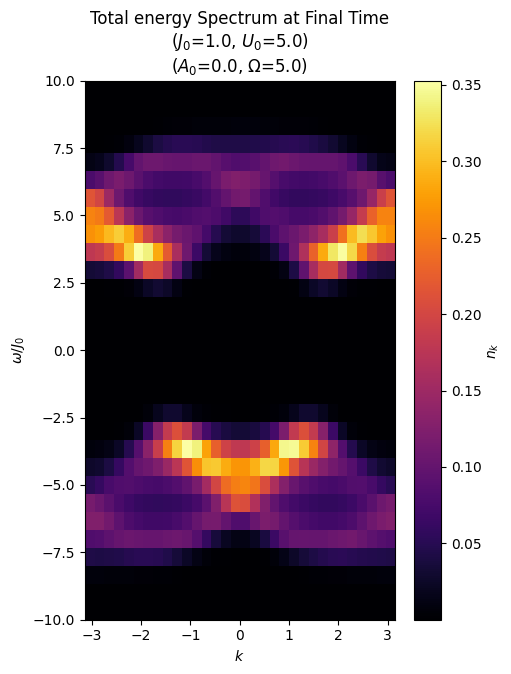

In [10]:
C_bottom_up, C_bottom_down = zip(*results_bottom)
C_top_up, C_top_down = zip(*results_top)

C_low = np.array(C_bottom_up + C_bottom_down)

C_top = np.array(C_top_up + C_top_down)

print(r"Lower band shape: {}".format(C_low.shape))
print(r"Upper band shape: {}".format(C_top.shape))

#####################################
###### Initializing n_k arrays ######
#####################################

n_low = np.zeros((N_omega, N_t, L), dtype=float)
n_top = np.zeros((N_omega, N_t, L), dtype=float)

k = np.linspace(-np.pi, np.pi, L)
l = np.arange(L)
phase_factor = np.exp(-1j * np.outer(k, l)) / np.sqrt(L)

#####################
###### Up spin ######
#####################

for wi in range(N_omega):
    for ti in range(N_t):
        n_low[wi, ti, :] = np.real(
            np.diag(phase_factor @ C_low[wi, ti, :, :] @ phase_factor.conj().T)
        )
        n_top[wi, ti, :] = 2 - np.real(
            np.diag(phase_factor @ C_top[wi, ti, :, :] @ phase_factor.conj().T)
        )

###################################
###### Plots Energy Spectrum ######
###################################

n_plot = n_low + n_top

plt.figure(figsize=(5, 7))
plt.imshow(
    n_plot[:, -1, :],
    extent=[k[0], k[-1], omega_scan[0], omega_scan[-1]],
    aspect='auto',
    cmap='inferno',
    origin='lower',
    vmin=np.min(n_plot[:, -1, :]),
    vmax=np.max(n_plot[:, -1, :]),
)

plt.colorbar(label=r'$n_k$')
plt.xlabel(r'$k$')
plt.ylabel(r'$\omega / J_0$')
plt.title(
    'Total energy Spectrum at Final Time' 
    + '\n' + 
    r'($J_0$={}, $U_0$={})'.format(J0, U0)
    + '\n' +
    r'($A_0$={}, $\Omega$={})'.format(A0, omega_drive)
    )
plt.show()



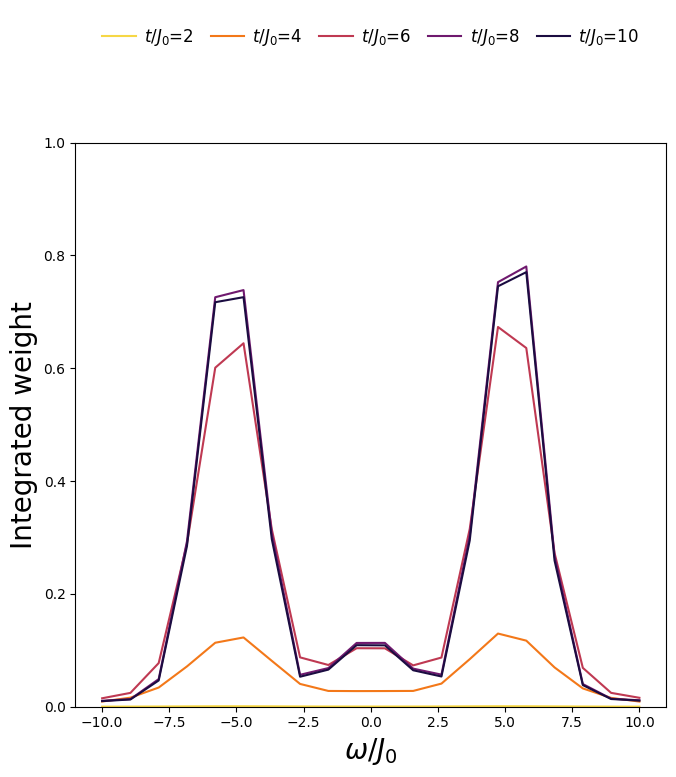

In [74]:
n_k_avg = np.sum(n_plot[:, :, :], axis=2) / len(k) 

# Plot n_k_avg as a function of omega
plt.figure(figsize=(7, 8))

for t_vals in [2.0, 4.0, 6.0, 8.0, 10.0]:
    ti = np.argmin(np.abs(times - t_vals))
    plt.plot(omega_scan, n_k_avg[:, ti], color=plt.cm.inferno(1.1-ti / N_t), label=r'$t /J_0$={:.0f}'.format(times[ti]))
plt.xlabel(r'$\omega / J_0$', fontsize=20)
plt.ylabel(r'Integrated weight', fontsize=20)

plt.ylim(0, 1)  
plt.legend(loc='upper center', bbox_to_anchor=(0.5, 1.25), ncol=5, fontsize=12,
           borderpad=1.0,           # Padding inside legend box
           labelspacing=0.5,        # Vertical space between entries
           handlelength=2.0,        # Length of legend handles
           handletextpad=0.5,       # Space between handle and text
           columnspacing=1.0,       # Space between columns
           frameon=False,            # Show/hide box
)
plt.tight_layout()
plt.show()